In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from tqdm import tqdm

In [7]:
# Step 1: GMM Data Generation
def generate_gmm_2d(n_samples=100000):
    gmm = GaussianMixture(n_components=3, covariance_type='full')
    gmm.means_ = np.array([[0, 0], [4, 4], [-4, 4]])
    gmm.covariances_ = np.array([[[1, 0.2], [0.2, 1]],
                                 [[1.2, -0.3], [-0.3, 1]],
                                 [[0.8, 0], [0, 0.8]]])
    gmm.weights_ = np.array([0.4, 0.3, 0.3])
    gmm.precisions_cholesky_ = np.linalg.cholesky(np.linalg.inv(gmm.covariances_))
    X, y = gmm.sample(n_samples)
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)

In [12]:
# Step 2: Define MLP Model
class DenoiseMLP(nn.Module):
    def __init__(self, dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(1).float() / 1000  # Shape: (batch_size, 1)
        x_input = torch.cat([x, t], dim=1)  # Shape: (batch_size, 3)
        return self.net(x_input)

# Step 3: Diffusion Settings
def get_schedule(T=1000):
    betas = torch.linspace(1e-4, 0.02, T)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    return betas, alphas, alphas_cumprod

def q_sample(x0, t, noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    return sqrt_alphas_cumprod[t].unsqueeze(1) * x0 + sqrt_one_minus_alphas_cumprod[t].unsqueeze(1) * noise

# Step 4: Train Diffusion Model
def train_diffusion(X, T=1000, n_epochs=1000, batch_size=128):
#     model = DenoiseMLP().to(device)
    model = DenoiseMLPDropout().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    betas, alphas, alphas_cumprod = get_schedule(T)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).to(device)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod).to(device)

    for epoch in tqdm(range(n_epochs)):
        idx = torch.randint(0, len(X), (batch_size,))
        x0 = X[idx].to(device)
        t = torch.randint(0, T, (batch_size,), device=device)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)
        pred = model(xt, t)
        loss = nn.MSELoss()(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

# Step 5: Uncertainty Estimation via MC Sampling
@torch.no_grad()
def estimate_uncertainty(model, xt, t, mc_samples=30):
    model.eval()
    preds = torch.stack([model(xt, t) for _ in range(mc_samples)], dim=0)
    return preds.mean(0), preds.std(0)

 69%|███████████████████████████▌            | 688/1000 [00:00<00:00, 3513.59it/s]

Epoch 0, Loss: 1.1090
Epoch 100, Loss: 0.2199
Epoch 200, Loss: 0.2648
Epoch 300, Loss: 0.2806
Epoch 400, Loss: 0.1986
Epoch 500, Loss: 0.2506
Epoch 600, Loss: 0.1679


100%|███████████████████████████████████████| 1000/1000 [00:00<00:00, 3552.97it/s]


Epoch 700, Loss: 0.1519
Epoch 800, Loss: 0.3162
Epoch 900, Loss: 0.3007


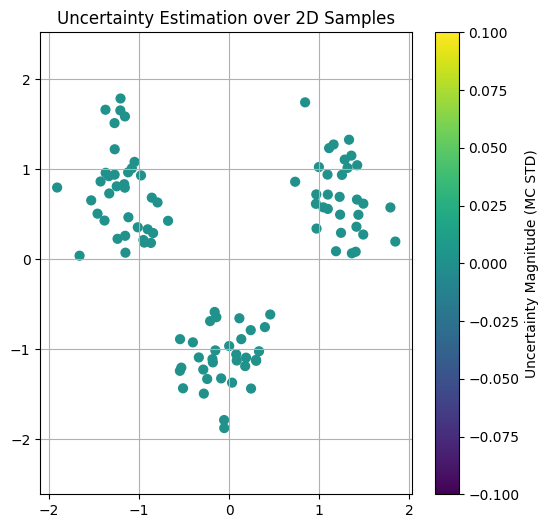

In [10]:
# Run all
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
X, y = generate_gmm_2d()
model = train_diffusion(X)

# Sample a few points and test uncertainty
sample_indices = torch.randint(0, len(X), (100,))
xt_test = X[sample_indices].to(device)
t_test = torch.randint(0, 1000, (len(sample_indices),), device=device)
mean_pred, std_pred = estimate_uncertainty(model, xt_test, t_test)

# Visualize predicted uncertainty (std) as magnitude
# Make sure uncertainty is positive
uncertainty_magnitude = std_pred.norm(dim=1).cpu().numpy()

# Plot with proper color range
plt.figure(figsize=(6, 6))
sc = plt.scatter(xt_test[:, 0].cpu(), xt_test[:, 1].cpu(),
                 c=uncertainty_magnitude, cmap='viridis', s=40,
                 vmin=0, vmax=uncertainty_magnitude.max())
plt.colorbar(sc, label="Uncertainty Magnitude (MC STD)")
plt.title("Uncertainty Estimation over 2D Samples")
plt.grid(True)
plt.axis("equal")
plt.show()

In [11]:
class DenoiseMLPDropout(nn.Module):
    def __init__(self, dim=2, dropout_p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(1).float() / 1000
        x_input = torch.cat([x, t], dim=1)
        return self.net(x_input)


In [13]:
@torch.no_grad()
def estimate_uncertainty_mc_dropout(model, xt, t, mc_samples=30):
    model.train()  # 👈 Keep dropout ON during inference
    preds = torch.stack([model(xt, t) for _ in range(mc_samples)], dim=0)
    return preds.mean(0), preds.std(0)


 50%|███████████████████▉                    | 497/1000 [00:00<00:00, 2535.77it/s]

Epoch 0, Loss: 1.0598
Epoch 100, Loss: 0.3444
Epoch 200, Loss: 0.2004
Epoch 300, Loss: 0.2744
Epoch 400, Loss: 0.3059
Epoch 500, Loss: 0.2290


100%|███████████████████████████████████████| 1000/1000 [00:00<00:00, 2604.65it/s]


Epoch 600, Loss: 0.2125
Epoch 700, Loss: 0.2648
Epoch 800, Loss: 0.3069
Epoch 900, Loss: 0.2321


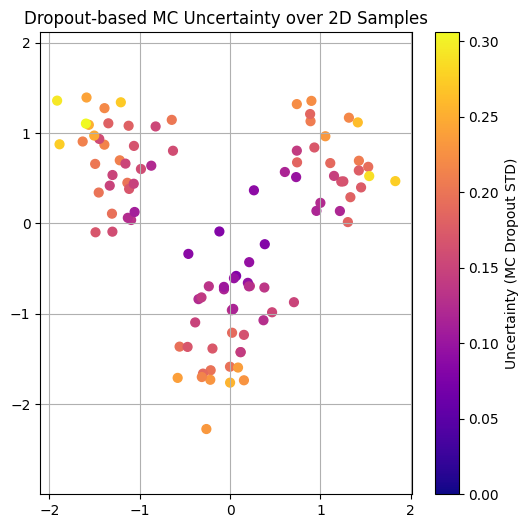

In [15]:
# Run all
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
X, y = generate_gmm_2d()
model = train_diffusion(X)

# Sample a few points and test uncertainty
sample_indices = torch.randint(0, len(X), (100,))
xt_test = X[sample_indices].to(device)
t_test = torch.randint(0, 1000, (len(sample_indices),), device=device)
mean_pred, std_pred = estimate_uncertainty_mc_dropout(model, xt_test, t_test)

uncertainty_magnitude = std_pred.norm(dim=1).cpu().numpy()

plt.figure(figsize=(6, 6))
sc = plt.scatter(xt_test[:, 0].cpu(), xt_test[:, 1].cpu(),
                 c=uncertainty_magnitude, cmap='plasma', s=40,
                 vmin=0, vmax=uncertainty_magnitude.max())
plt.colorbar(sc, label="Uncertainty (MC Dropout STD)")
plt.title("Dropout-based MC Uncertainty over 2D Samples")
plt.grid(True)
plt.axis("equal")
plt.show()


## Data Generation using GMM

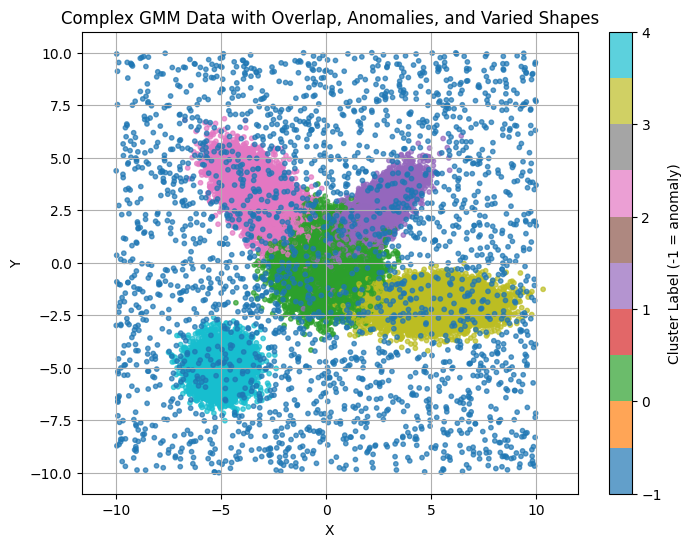

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def generate_complex_gmm_data(n_samples=50000, anomaly_ratio=0.05, random_state=42):
    np.random.seed(random_state)
    
    # Define complex GMM parameters
    means = [
        np.array([0, 0]),        # Circular, centered
        np.array([2, 2]),        # Close to center, will overlap
        np.array([-3, 3]),       # Tilted ellipse
        np.array([5, -2]),       # Elongated
        np.array([-5, -5])       # Far, sparse cluster
    ]
    
    covariances = [
        np.array([[1, 0], [0, 1]]),            # Circular
        np.array([[1, 0.8], [0.8, 1]]),        # Overlapping and tilted
        np.array([[1, -0.6], [-0.6, 1]]),      # Tilted ellipse
        np.array([[2, 0], [0, 0.3]]),          # Elongated horizontally
        np.array([[0.5, 0], [0, 0.5]])         # Compact cluster
    ]
    
    weights = [0.25, 0.25, 0.2, 0.2, 0.1]  # Imbalanced weights

    n_components = len(weights)
    weights = np.array(weights) / np.sum(weights)

    # Allocate points per cluster
    components = np.random.choice(n_components, size=n_samples, p=weights)
    data = np.zeros((n_samples, 2))
    labels = np.zeros(n_samples, dtype=int)

    for i in range(n_components):
        n_i = np.sum(components == i)
        if n_i > 0:
            data[components == i] = np.random.multivariate_normal(
                means[i], covariances[i], size=n_i
            )
            labels[components == i] = i

    # Add anomaly/outlier points
    n_anomalies = int(anomaly_ratio * n_samples)
    anomalies = np.random.uniform(low=-10, high=10, size=(n_anomalies, 2))
    anomaly_labels = np.full(n_anomalies, -1)

    data = np.vstack([data, anomalies])
    labels = np.concatenate([labels, anomaly_labels])

    return data, labels

# Generate data
data, labels = generate_complex_gmm_data()

# Visualize
plt.figure(figsize=(8, 6))
scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
plt.title("Complex GMM Data with Overlap, Anomalies, and Varied Shapes")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis("equal")
plt.colorbar(scatter, label='Cluster Label (-1 = anomaly)')
plt.show()


100%|███████████████████████████████████████| 1000/1000 [00:00<00:00, 2527.63it/s]


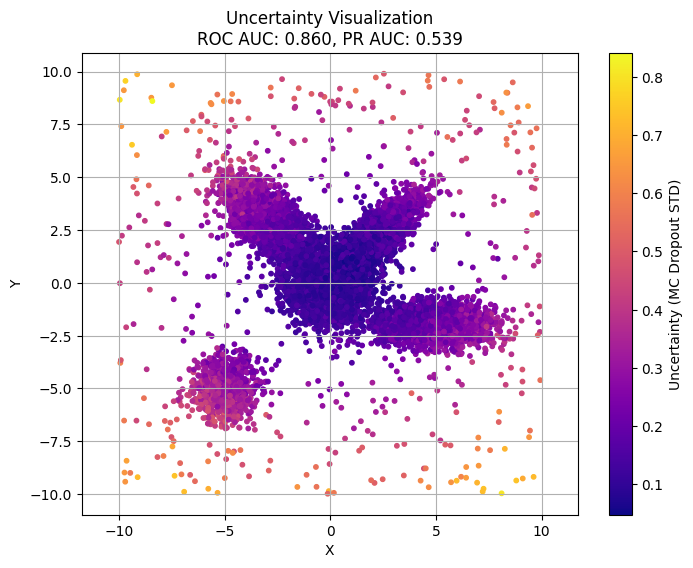

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Step 1: Generate Complex GMM Data
def generate_complex_gmm_data(n_samples=10000, anomaly_ratio=0.05, random_state=42):
    np.random.seed(random_state)
    
    means = [
        np.array([0, 0]),
        np.array([2, 2]),
        np.array([-3, 3]),
        np.array([5, -2]),
        np.array([-5, -5])
    ]
    
    covariances = [
        np.array([[1, 0], [0, 1]]),
        np.array([[1, 0.8], [0.8, 1]]),
        np.array([[1, -0.6], [-0.6, 1]]),
        np.array([[2, 0], [0, 0.3]]),
        np.array([[0.5, 0], [0, 0.5]])
    ]
    
    weights = [0.25, 0.25, 0.2, 0.2, 0.1]
    n_components = len(weights)
    weights = np.array(weights) / np.sum(weights)

    components = np.random.choice(n_components, size=n_samples, p=weights)
    data = np.zeros((n_samples, 2))
    labels = np.zeros(n_samples, dtype=int)

    for i in range(n_components):
        n_i = np.sum(components == i)
        if n_i > 0:
            data[components == i] = np.random.multivariate_normal(means[i], covariances[i], size=n_i)
            labels[components == i] = i

    n_anomalies = int(anomaly_ratio * n_samples)
    anomalies = np.random.uniform(low=-10, high=10, size=(n_anomalies, 2))
    anomaly_labels = np.full(n_anomalies, -1)

    data = np.vstack([data, anomalies])
    labels = np.concatenate([labels, anomaly_labels])

    return data, labels

# Step 2: Define MLP with Dropout
class DenoiseMLPDropout(nn.Module):
    def __init__(self, dim=2, dropout_p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(1).float() / 1000
        x_input = torch.cat([x, t], dim=1)
        return self.net(x_input)

# Step 3: Diffusion Schedule
def get_schedule(T=1000):
    betas = torch.linspace(1e-4, 0.02, T)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    return betas, alphas, alphas_cumprod

def q_sample(x0, t, noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    return sqrt_alphas_cumprod[t].unsqueeze(1) * x0 + sqrt_one_minus_alphas_cumprod[t].unsqueeze(1) * noise

# Step 4: Training Function
def train_diffusion(X, T=1000, n_epochs=1000, batch_size=128):
    model = DenoiseMLPDropout().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    betas, alphas, alphas_cumprod = get_schedule(T)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).to(device)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod).to(device)

    for epoch in tqdm(range(n_epochs)):
        idx = torch.randint(0, len(X), (batch_size,))
        x0 = X[idx].to(device)
        t = torch.randint(0, T, (batch_size,), device=device)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)
        pred = model(xt, t)
        loss = nn.MSELoss()(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod

# Step 5: Uncertainty Estimation
@torch.no_grad()
def estimate_uncertainty_mc_dropout(model, xt, t, mc_samples=30):
    model.train()
    preds = torch.stack([model(xt, t) for _ in range(mc_samples)], dim=0)
    return preds.mean(0), preds.std(0)

# Step 6: Prepare Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data, labels = generate_complex_gmm_data()
normal_data = data[labels != -1]
anomaly_data = data[labels == -1]
mean = normal_data.mean(axis=0)
std = normal_data.std(axis=0)
data_normalized = (data - mean) / std
X_train = torch.tensor(data_normalized[labels != -1], dtype=torch.float32)
X_test = torch.tensor(data_normalized, dtype=torch.float32)
y_true = (labels == -1).astype(int)  # 1 for anomaly, 0 for normal

# Step 7: Train
model, sqrt_ac, sqrt_om_ac = train_diffusion(X_train)

# Step 8: Estimate Uncertainty
sample_indices = torch.arange(len(X_test))
xt_test = X_test[sample_indices].to(device)
t_test = torch.randint(0, 1000, (len(sample_indices),), device=device)
_, std_pred = estimate_uncertainty_mc_dropout(model, xt_test, t_test)
uncertainty_magnitude = std_pred.norm(dim=1).cpu().numpy()

# Step 9: Evaluate
roc_auc = roc_auc_score(y_true, uncertainty_magnitude)
precision, recall, _ = precision_recall_curve(y_true, uncertainty_magnitude)
pr_auc = auc(recall, precision)

# Step 10: Visualize
plt.figure(figsize=(8, 6))
sc = plt.scatter(data[:, 0], data[:, 1], c=uncertainty_magnitude, cmap='plasma', s=10)
plt.colorbar(sc, label="Uncertainty (MC Dropout STD)")
plt.title(f"Uncertainty Visualization\nROC AUC: {roc_auc:.3f}, PR AUC: {pr_auc:.3f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis("equal")
plt.show()


##  Complex GMM + anomalies	

### Complex Dataset Generation

Saved as 'gmm_synthetic_large_data.csv'


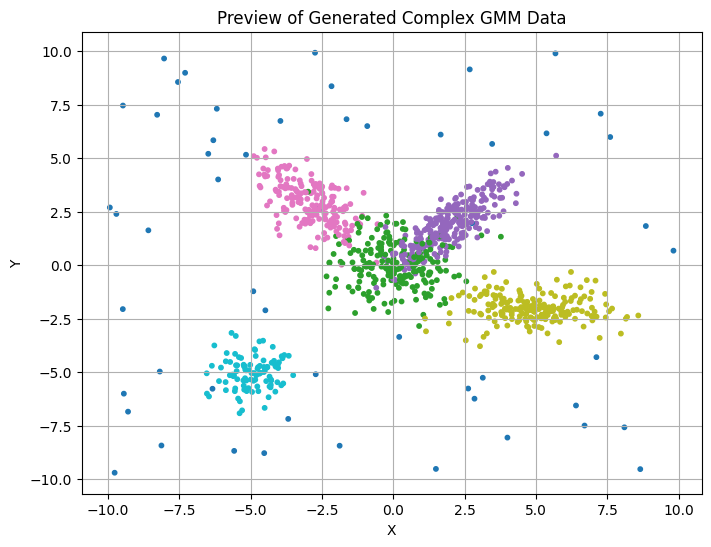

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_complex_gmm_data(n_samples=100000, anomaly_ratio=0.05, random_state=42):
    np.random.seed(random_state)
    
    means = [
        np.array([0, 0]),
        np.array([2, 2]),
        np.array([-3, 3]),
        np.array([5, -2]),
        np.array([-5, -5])
    ]
    
    covariances = [
        np.array([[1, 0], [0, 1]]),
        np.array([[1, 0.8], [0.8, 1]]),
        np.array([[1, -0.6], [-0.6, 1]]),
        np.array([[2, 0], [0, 0.3]]),
        np.array([[0.5, 0], [0, 0.5]])
    ]
    
    weights = [0.25, 0.25, 0.2, 0.2, 0.1]
    weights = np.array(weights) / np.sum(weights)
    n_components = len(weights)
    
    components = np.random.choice(n_components, size=n_samples, p=weights)
    data = np.zeros((n_samples, 2))
    labels = np.zeros(n_samples, dtype=int)
    
    for i in range(n_components):
        n_i = np.sum(components == i)
        data[components == i] = np.random.multivariate_normal(means[i], covariances[i], size=n_i)
        labels[components == i] = i

    n_anomalies = int(anomaly_ratio * n_samples)
    anomalies = np.random.uniform(low=-10, high=10, size=(n_anomalies, 2))
    anomaly_labels = np.full(n_anomalies, -1)

    full_data = np.vstack([data, anomalies])
    full_labels = np.concatenate([labels, anomaly_labels])
    
    df = pd.DataFrame(full_data, columns=['x', 'y'])
    df['label'] = full_labels

    df.to_csv("gmm_synthetic_large_data.csv", index=False)
    print("Saved as 'gmm_synthetic_large_data.csv'")
    
    # Optional: visualize a sample
    sample_idx = np.random.choice(len(full_data), size=1000, replace=False)
    plt.figure(figsize=(8, 6))
    plt.scatter(full_data[sample_idx, 0], full_data[sample_idx, 1],
                c=full_labels[sample_idx], cmap='tab10', s=10)
    plt.title("Preview of Generated Complex GMM Data")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

# Run it
generate_complex_gmm_data()


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from tqdm import tqdm

# ---------------------------
# 1. Dataset Class
# ---------------------------
class GMMDataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file)[['x', 'y']].values.astype(np.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx])

# ---------------------------
# 2. Diffusion Model
# ---------------------------
class DiffusionMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, time_embed_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.ReLU(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )
        self.model = nn.Sequential(
            nn.Linear(input_dim + time_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.model(x_input)

# ---------------------------
# 3. Diffusion Schedule
# ---------------------------
def linear_beta_schedule(timesteps):
    beta_start = 1e-4
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)


def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    betas = torch.clip(betas, 0.0001, 0.9999)
    return betas


def prepare_diffusion_schedules(T, device):
    betas = linear_beta_schedule(T).to(device)
    #betas = cosine_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]])

    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

    return {
        'betas': betas,
        'alphas': alphas,
        'sqrt_recip_alphas': sqrt_recip_alphas,
        'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'posterior_variance': posterior_variance
    }

# def cosine_beta_schedule(timesteps, s=0.008):
#     import numpy as np
#     x = torch.linspace(0, timesteps, timesteps + 1)
#     alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * np.pi * 0.5) ** 2
#     alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
#     betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
#     return torch.clip(betas, 0.0001, 0.9999)

# def prepare_diffusion_schedules(timesteps, device='cpu'):
#     betas = cosine_beta_schedule(timesteps).to(device)
#     alphas = 1.0 - betas
#     alphas_cumprod = torch.cumprod(alphas, dim=0)
    
#     sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
#     sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)
#     sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

#     posterior_variance = betas * (1.0 - alphas_cumprod[:-1]) / (1.0 - alphas_cumprod[1:])
#     posterior_variance = torch.cat([posterior_variance[0:1], posterior_variance])  # match length

#     return {
#         'betas': betas,
#         'alphas': alphas,
#         'alphas_cumprod': alphas_cumprod,
#         'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
#         'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
#         'sqrt_recip_alphas': sqrt_recip_alphas,
#         'posterior_variance': posterior_variance,
#     }


# ---------------------------
# 4. Reverse Diffusion (Sampling)
# ---------------------------
@torch.no_grad()
def sample_reverse_diffusion(model, T, schedules, num_samples=1000, device='cpu'):
    model.eval()
    x_t = torch.randn((num_samples, 2), device=device)
    for t in reversed(range(T)):
        t_tensor = torch.full((num_samples, 1), t / T, device=device)
        beta_t = schedules['betas'][t]
        sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
        sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]

        model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x_t, t_tensor))

        if t > 0:
            noise = torch.randn_like(x_t)
            variance = schedules['posterior_variance'][t]
            x_t = model_mean + torch.sqrt(variance) * noise
        else:
            x_t = model_mean
    return x_t.cpu().numpy()

# ---------------------------
# 5. Evaluate and Visualize
# ---------------------------
def evaluate_reconstruction(original_data, generated_data):
    mse = np.mean((original_data - generated_data) ** 2)
    print(f"Reconstruction MSE: {mse:.4f}")
    plt.figure(figsize=(8, 6))
    plt.scatter(original_data[:, 0], original_data[:, 1], color='blue', alpha=0.5, label='Original')
    plt.scatter(generated_data[:, 0], generated_data[:, 1], color='red', alpha=0.5, label='Generated')
    plt.legend()
    plt.title("Full Reverse Diffusion: Original vs. Generated")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

# ---------------------------
# 6. Main
# ---------------------------

Epoch 1/10, Loss: 0.480230
Epoch 2/10, Loss: 0.431018
Epoch 3/10, Loss: 0.423553
Epoch 4/10, Loss: 0.417756
Epoch 5/10, Loss: 0.419099
Epoch 6/10, Loss: 0.414887
Epoch 7/10, Loss: 0.419135
Epoch 8/10, Loss: 0.412703
Epoch 9/10, Loss: 0.414140
Epoch 10/10, Loss: 0.410977
Reconstruction MSE: 19.1363


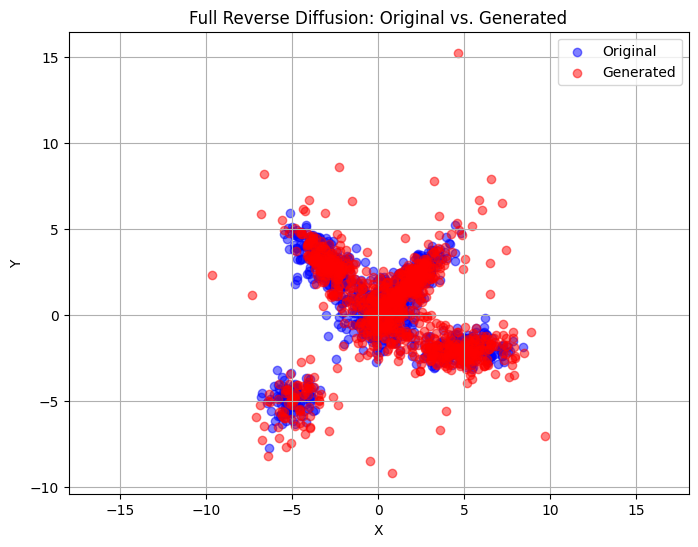

In [3]:
csv_file = "gmm_synthetic_large_data.csv"  # update as needed
batch_size = 256
epochs = 10
timesteps = 1000
device = torch.device('mps' if torch.cuda.is_available() else 'cpu')

dataset = GMMDataset(csv_file)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
model = DiffusionMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

schedules = prepare_diffusion_schedules(timesteps, device)
sqrt_alphas_cumprod = schedules['sqrt_alphas_cumprod']
sqrt_one_minus_alphas_cumprod = schedules['sqrt_one_minus_alphas_cumprod']
mse_loss = nn.MSELoss()

model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in dataloader:
        batch = batch.to(device)
        t = torch.randint(0, timesteps, (batch.shape[0],), device=device)
        t_norm = t.float().unsqueeze(1) / timesteps
        noise = torch.randn_like(batch)
        x_t = schedules['sqrt_alphas_cumprod'][t].unsqueeze(1) * batch + \
              schedules['sqrt_one_minus_alphas_cumprod'][t].unsqueeze(1) * noise
        pred_noise = model(x_t, t_norm)
        loss = mse_loss(pred_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

# Full Reverse Diffusion
generated = sample_reverse_diffusion(model, timesteps, schedules, num_samples=1000, device=device)
original = dataset[:1000].numpy()
evaluate_reconstruction(original, generated)


MSE: 38.2727
Chamfer Distance: 0.3504


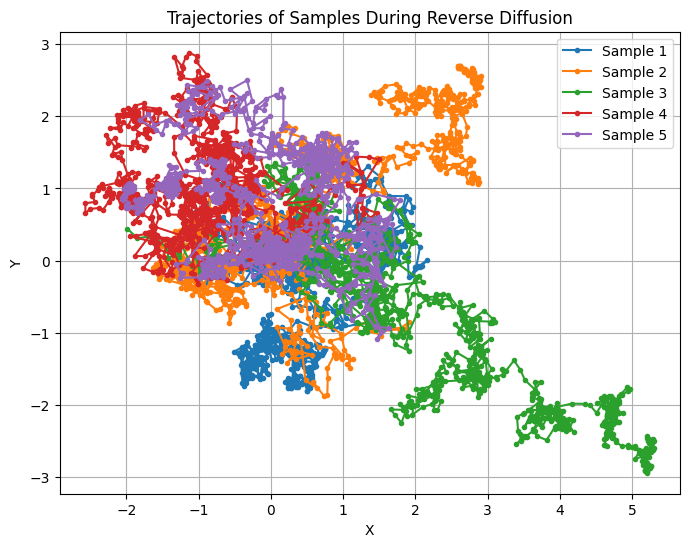

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances

# 1. Mean Squared Error (MSE)
def compute_mse(real, generated):
    return np.mean(np.sum((real - generated)**2, axis=1))

# 2. Chamfer Distance (symmetric)
def compute_chamfer_distance(A, B):
    """
    Compute the Chamfer Distance between two point sets A and B
    A, B: (N, D) numpy arrays
    """
    dists_A_to_B = cdist(A, B)
    dists_B_to_A = cdist(B, A)

    chamfer = np.mean(np.min(dists_A_to_B, axis=1)) + np.mean(np.min(dists_B_to_A, axis=1))
    return chamfer

# Load samples from the last cell
# Fix for original
T = timesteps
original_samples = np.array([dataset[i].numpy() for i in range(1000)])  # or use pd.read_csv(...)
generated_samples = sample_reverse_diffusion(model, T, schedules, num_samples=1000, device=device)

# Already have this from sampling
# generated = sample_reverse_diffusion(...)

# Now evaluate
mse = compute_mse(original_samples, generated)
chamfer = compute_chamfer_distance(original_samples, generated)

print(f"MSE: {mse:.4f}")
print(f"Chamfer Distance: {chamfer:.4f}")


# Compute metrics
mse = compute_mse(original_samples, generated_samples)
chamfer = compute_chamfer_distance(original_samples, generated_samples)


# Sample Trajectory Visualization (pick a few points)
def plot_sample_trajectories(model, schedules, T, device='cpu', num_points=5):
    model.eval()
    x_t = torch.randn((num_points, 2), device=device)
    trajectory = [x_t.detach().cpu().numpy()]
    for t in reversed(range(T)):
        t_tensor = torch.full((num_points, 1), t / T, device=device)
        beta_t = schedules['betas'][t]
        sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
        sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]
        model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x_t, t_tensor))

        if t > 0:
            noise = torch.randn_like(x_t)
            variance = schedules['posterior_variance'][t]
            x_t = model_mean + torch.sqrt(variance) * noise
        else:
            x_t = model_mean
        trajectory.append(x_t.detach().cpu().numpy())

    # Plot trajectories
    trajectory = np.array(trajectory)  # (T+1, N, 2)
    plt.figure(figsize=(8, 6))
    for i in range(num_points):
        plt.plot(trajectory[:, i, 0], trajectory[:, i, 1], marker='o', markersize=3, label=f'Sample {i+1}')
    plt.title("Trajectories of Samples During Reverse Diffusion")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()
    plt.axis("equal")
    plt.show()

import pandas as pd
dataframe=pd.DataFrame({
    "Metric": ["MSE", "Chamfer Distance"],
    "Value": [mse, chamfer]
})

plot_sample_trajectories(model, schedules, T=1000, device=device)



In [6]:
def sample_multiple_reverse_diffusions(model, T, schedules, num_samples=1000, n_repeats=10, device='cpu'):
    model.eval()
    all_outputs = []

    for _ in range(n_repeats):
        x_t = torch.randn((num_samples, 2), device=device)
        for t in reversed(range(T)):
            t_tensor = torch.full((num_samples, 1), t / T, device=device)
            beta_t = schedules['betas'][t]
            sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
            sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]
            model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x_t, t_tensor))

            if t > 0:
                noise = torch.randn_like(x_t)
                variance = schedules['posterior_variance'][t]
                x_t = model_mean + torch.sqrt(variance) * noise
            else:
                x_t = model_mean

        all_outputs.append(x_t.detach().cpu().numpy())

    all_outputs = np.stack(all_outputs, axis=0)  # shape: (n_repeats, num_samples, 2)
    return all_outputs


In [7]:
samples = sample_multiple_reverse_diffusions(model, T, schedules, num_samples=1000, n_repeats=10, device=device)

# Compute variance across samples for each point
# samples shape: (10, 1000, 2)
uncertainty = np.var(samples, axis=0)  # shape: (1000, 2)

# Optionally: compute norm of variance (scalar uncertainty per point)
uncertainty_norm = np.linalg.norm(uncertainty, axis=1)  # shape: (1000,)


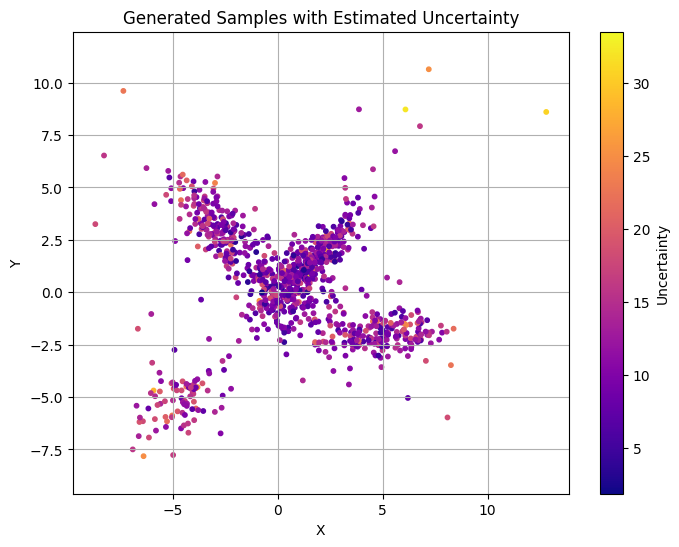

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(samples[0, :, 0], samples[0, :, 1], c=uncertainty_norm, cmap='plasma', s=10)
plt.colorbar(label="Uncertainty")
plt.title("Generated Samples with Estimated Uncertainty")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.show()


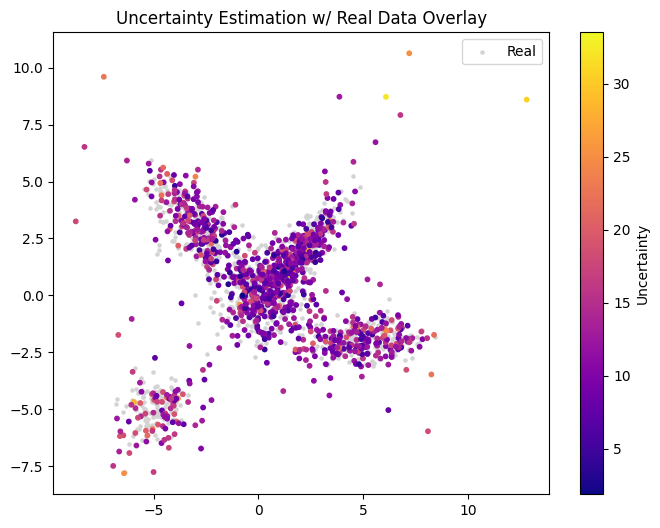

In [9]:
real_data = np.array([dataset[i].numpy() for i in range(1000)])
plt.figure(figsize=(8, 6))
plt.scatter(real_data[:, 0], real_data[:, 1], color='lightgrey', s=5, label='Real')
plt.scatter(samples[0, :, 0], samples[0, :, 1], c=uncertainty_norm, cmap='plasma', s=10)
plt.colorbar(label="Uncertainty")
plt.legend()
plt.title("Uncertainty Estimation w/ Real Data Overlay")
plt.show()


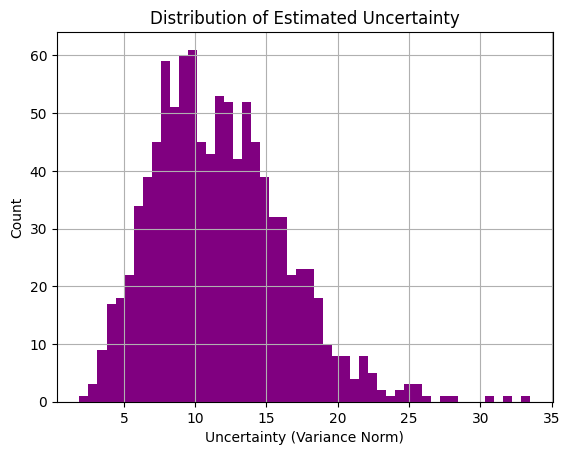

In [10]:
plt.hist(uncertainty_norm, bins=50, color='purple')
plt.xlabel("Uncertainty (Variance Norm)")
plt.ylabel("Count")
plt.title("Distribution of Estimated Uncertainty")
plt.grid(True)
plt.show()


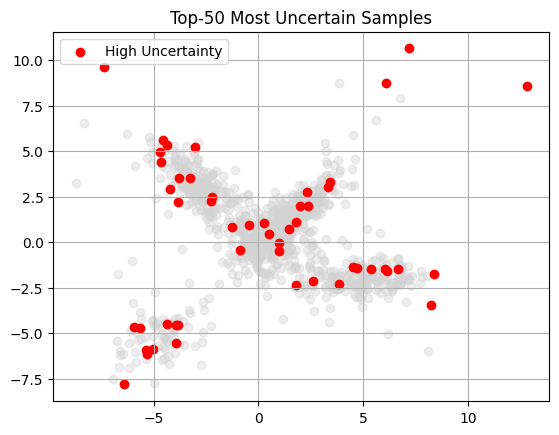

In [11]:
topk_indices = np.argsort(-uncertainty_norm)[:50]
high_uncertain_points = samples[0][topk_indices]

plt.scatter(samples[0][:, 0], samples[0][:, 1], color='lightgrey', alpha=0.4)
plt.scatter(high_uncertain_points[:, 0], high_uncertain_points[:, 1], color='red', label='High Uncertainty')
plt.legend()
plt.title("Top-50 Most Uncertain Samples")
plt.grid(True)
plt.show()


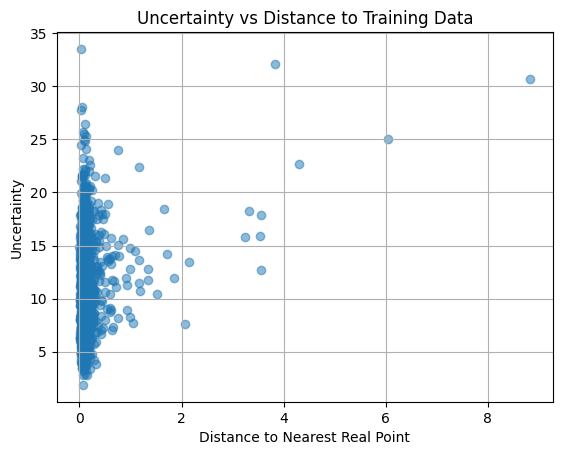

In [12]:
from scipy.spatial import cKDTree

tree = cKDTree(real_data)
dists, _ = tree.query(samples[0], k=1)  # Nearest real point
plt.scatter(dists, uncertainty_norm, alpha=0.5)
plt.xlabel("Distance to Nearest Real Point")
plt.ylabel("Uncertainty")
plt.title("Uncertainty vs Distance to Training Data")
plt.grid(True)
plt.show()


In [13]:
def estimate_uncertainty(model, schedules, T=1000, num_samples=500, n_repeats=10, device='cpu'):
    model.eval()
    all_outputs = []

    # Infer dimensionality
    input_dim = model.model[-1].out_features  # typically 2D output
    time_embed_dim = model.time_embed[-1].out_features

    for _ in range(n_repeats):
        x_t = torch.randn((num_samples, input_dim), device=device)
        
        for t in reversed(range(T)):
            t_tensor = torch.full((num_samples, 1), t / T, device=device)

            beta_t = schedules['betas'][t]
            sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
            sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]

            # Reconstruct input to match model input shape
            t_embed = model.time_embed(t_tensor)
            x_input = torch.cat([x_t, t_embed], dim=1)

            pred_noise = model.model(x_input)  # skip forward() to avoid extra concat again

            model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * pred_noise)

            if t > 0:
                noise = torch.randn_like(x_t)
                variance = schedules['posterior_variance'][t]
                x_t = model_mean + torch.sqrt(variance) * noise
            else:
                x_t = model_mean

        all_outputs.append(x_t.cpu().detach().numpy())

    all_outputs = np.stack(all_outputs, axis=0)
    uncertainty = np.var(all_outputs, axis=0)

    return uncertainty, all_outputs[0]


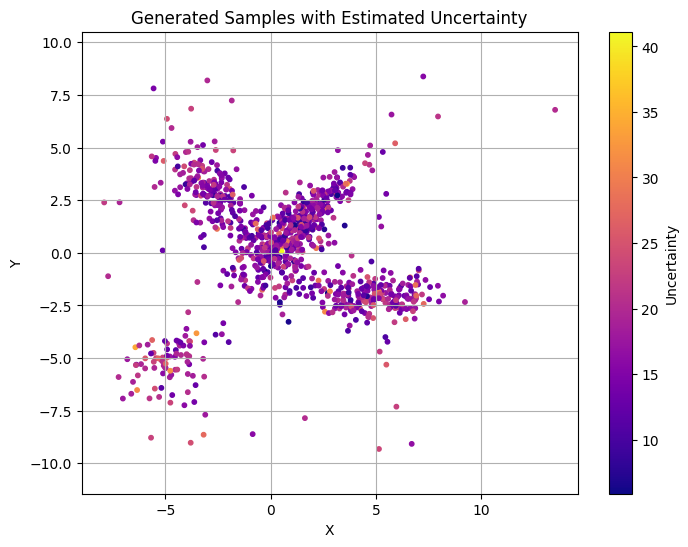

In [14]:
uncertainty, samples = estimate_uncertainty(model, schedules, T=1000, num_samples=1000, n_repeats=20, device=device)

uncertainty_scalar = np.sum(uncertainty, axis=1)

plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], c=uncertainty_scalar, cmap='plasma', s=10)
plt.colorbar(label='Uncertainty')
plt.title("Generated Samples with Estimated Uncertainty")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis("equal")
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

def analyze_uncertainty(model, dataset, schedules, T=1000, num_samples=1000, n_repeats=10, device='cpu'):
    print("Sampling with Monte Carlo for uncertainty estimation...")
    
    # Step 1: Monte Carlo sampling
    def sample_multiple(model, T, schedules, num_samples, n_repeats, device):
        all_outputs = []
        for _ in range(n_repeats):
            x_t = torch.randn((num_samples, 2), device=device)
            for t in reversed(range(T)):
                t_tensor = torch.full((num_samples, 1), t / T, device=device)
                beta_t = schedules['betas'][t]
                sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
                sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]
                model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x_t, t_tensor))
                if t > 0:
                    noise = torch.randn_like(x_t)
                    variance = schedules['posterior_variance'][t]
                    x_t = model_mean + torch.sqrt(variance) * noise
                else:
                    x_t = model_mean
            all_outputs.append(x_t.detach().cpu().numpy())
        return np.stack(all_outputs, axis=0)

    # Step 2: Sample multiple and compute uncertainty
    samples = sample_multiple(model, T, schedules, num_samples, n_repeats, device)
    uncertainty = np.var(samples, axis=0)  # (N, 2)
    uncertainty_norm = np.linalg.norm(uncertainty, axis=1)
    generated = samples[0]  # take one run for plotting

    # Step 3: Plot histogram
    plt.figure(figsize=(6, 5))
    plt.hist(uncertainty_norm, bins=50, color='purple')
    plt.xlabel("Uncertainty (Variance Norm)")
    plt.ylabel("Count")
    plt.title("Distribution of Estimated Uncertainty")
    plt.grid(True)
    plt.show()

    # Step 4: Real vs. Generated Uncertainty Plot
    real_data = np.array([dataset[i].numpy() for i in range(num_samples)])
    plt.figure(figsize=(8, 6))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=5, color='lightgrey', label='Real Data')
    plt.scatter(generated[:, 0], generated[:, 1], c=uncertainty_norm, cmap='plasma', s=10, label='Generated')
    plt.colorbar(label="Uncertainty")
    plt.title("Generated Samples with Estimated Uncertainty")
    plt.legend()
    plt.grid(True)
    plt.axis("equal")
    plt.show()

    # Step 5: Correlation between uncertainty and distance to training data
    tree = cKDTree(real_data)
    dists, _ = tree.query(generated, k=1)
    plt.figure(figsize=(6, 5))
    plt.scatter(dists, uncertainty_norm, alpha=0.5)
    plt.xlabel("Distance to Nearest Real Point")
    plt.ylabel("Uncertainty")
    plt.title("Uncertainty vs Distance to Training Data")
    plt.grid(True)
    plt.show()

    print("✅ Uncertainty analysis completed.")


Sampling with Monte Carlo for uncertainty estimation...


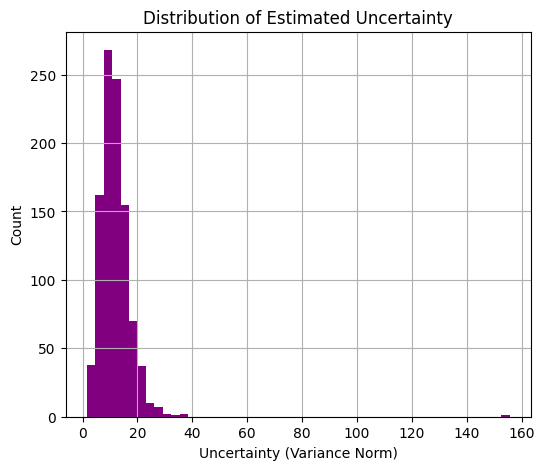

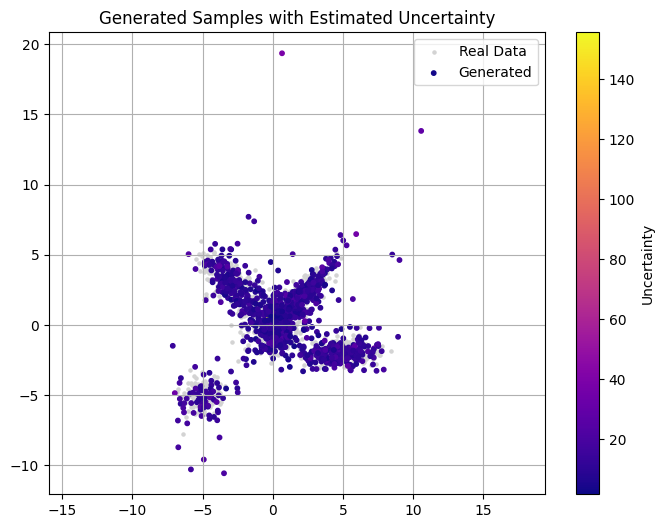

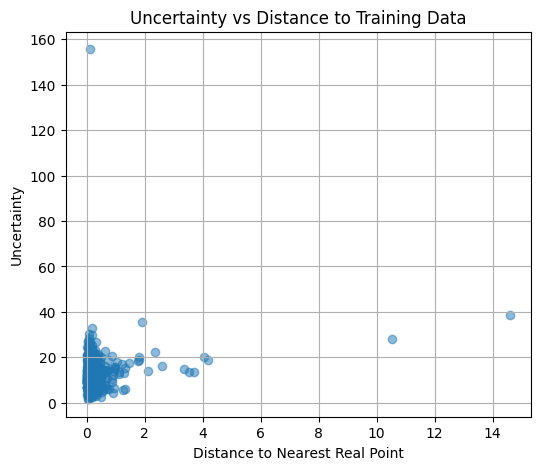

✅ Uncertainty analysis completed.


In [16]:
analyze_uncertainty(model, dataset, schedules, T=1000, num_samples=1000, n_repeats=10, device=device)

In [38]:
# Load labels from your CSV
import pandas as pd

df = pd.read_csv("gmm_synthetic_large_data.csv")  # or your file
labels = df['label'].values[:len(uncertainty_norm)]  # align length to sampled points


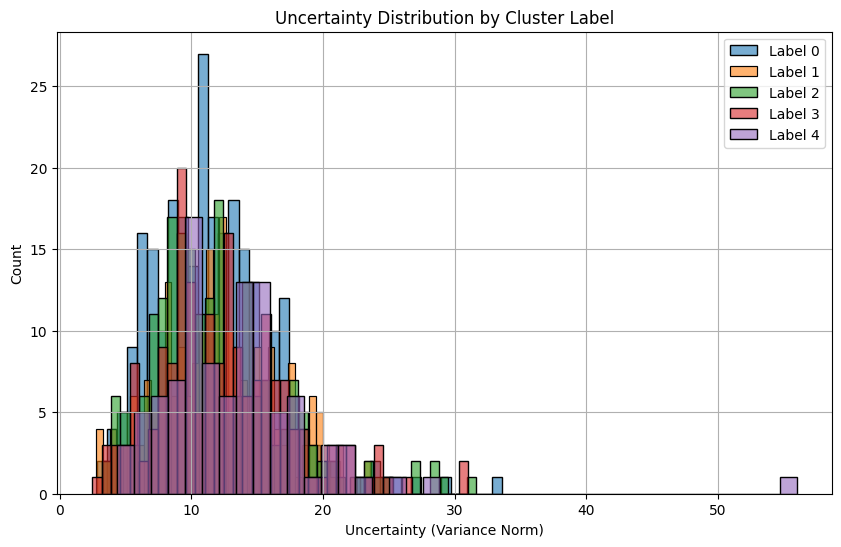

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
for label in np.unique(labels):
    mask = labels == label
    sns.histplot(uncertainty_norm[mask], bins=40, kde=False, label=f'Label {label}', alpha=0.6)

plt.xlabel("Uncertainty (Variance Norm)")
plt.ylabel("Count")
plt.title("Uncertainty Distribution by Cluster Label")
plt.legend()
plt.grid(True)
plt.show()


Current uncertainty estimation method is:

- Multiple full reverse diffusion samplings (sample_multiple_reverse_diffusions)

- Variance computation across samples

- Norm of variance as uncertainty score

✅ This is Monte Carlo sampling of the full reverse diffusion process.

✅ No randomness inside the model parameters — only randomness from the input noise and diffusion sampling steps.

✅ Result: you estimate epistemic uncertainty by how different final samples are across repeated diffusion processes.



### MC Dropout

In [17]:
class DiffusionMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, time_embed_dim=32, dropout_rate=0.1):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.ReLU(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )
        self.model = nn.Sequential(
            nn.Linear(input_dim + time_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.model(x_input)


In [18]:
@torch.no_grad()
def sample_reverse_diffusion_with_dropout(model, T, schedules, num_samples=1000, device='cpu', n_repeats=10):
    model.train()  # <--- force dropout ON even during sampling
    all_outputs = []

    for _ in range(n_repeats):
        x_t = torch.randn((num_samples, 2), device=device)
        for t in reversed(range(T)):
            t_tensor = torch.full((num_samples, 1), t / T, device=device)
            beta_t = schedules['betas'][t]
            sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
            sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]
            model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x_t, t_tensor))

            if t > 0:
                noise = torch.randn_like(x_t)
                variance = schedules['posterior_variance'][t]
                x_t = model_mean + torch.sqrt(variance) * noise
            else:
                x_t = model_mean

        all_outputs.append(x_t.detach().cpu().numpy())

    model.eval()  # reset back to normal eval mode
    all_outputs = np.stack(all_outputs, axis=0)
    return all_outputs


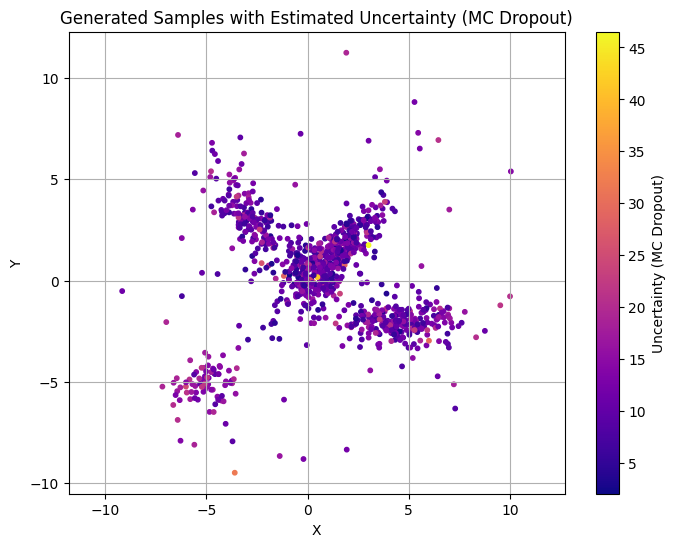

In [19]:
samples_dropout = sample_reverse_diffusion_with_dropout(model, T, schedules, num_samples=1000, device=device, n_repeats=10)
uncertainty_dropout = np.var(samples_dropout, axis=0)
uncertainty_dropout_norm = np.linalg.norm(uncertainty_dropout, axis=1)

plt.figure(figsize=(8, 6))
plt.scatter(samples_dropout[0, :, 0], samples_dropout[0, :, 1], c=uncertainty_dropout_norm, cmap='plasma', s=10)
plt.colorbar(label="Uncertainty (MC Dropout)")
plt.title("Generated Samples with Estimated Uncertainty (MC Dropout)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.show()


In [20]:
print(f"Mean Uncertainty (MC Reverse Diffusion): {np.mean(uncertainty_norm):.4f}")
print(f"Std Dev of Uncertainty (MC Reverse Diffusion): {np.std(uncertainty_norm):.4f}")

print(f"Mean Uncertainty (MC Dropout): {np.mean(uncertainty_dropout_norm):.4f}")
print(f"Std Dev of Uncertainty (MC Dropout): {np.std(uncertainty_dropout_norm):.4f}")


Mean Uncertainty (MC Reverse Diffusion): 11.6888
Std Dev of Uncertainty (MC Reverse Diffusion): 4.5985
Mean Uncertainty (MC Dropout): 11.6853
Std Dev of Uncertainty (MC Dropout): 4.8886


In [21]:
from scipy.stats import pearsonr

corr, _ = pearsonr(uncertainty_norm, uncertainty_dropout_norm)
print(f"Pearson Correlation between uncertainties: {corr:.4f}")


Pearson Correlation between uncertainties: -0.0323


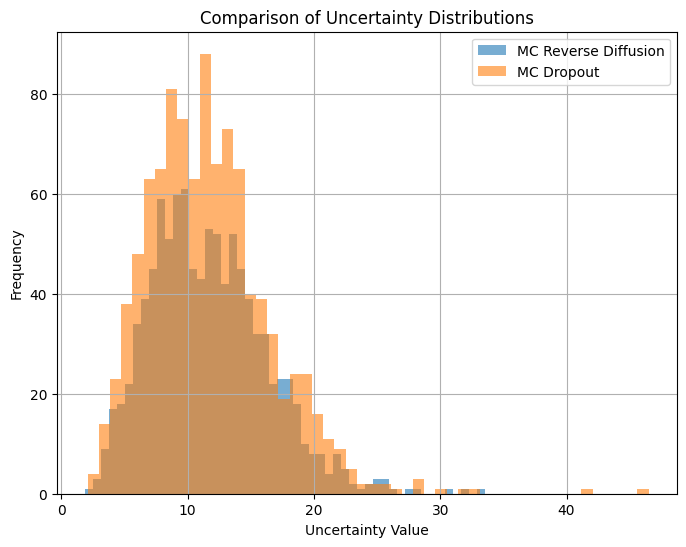

In [22]:
plt.figure(figsize=(8, 6))
plt.hist(uncertainty_norm, bins=50, alpha=0.6, label='MC Reverse Diffusion')
plt.hist(uncertainty_dropout_norm, bins=50, alpha=0.6, label='MC Dropout')
plt.xlabel('Uncertainty Value')
plt.ylabel('Frequency')
plt.title('Comparison of Uncertainty Distributions')
plt.legend()
plt.grid(True)
plt.show()


## Boston Housing Price dataset

In [48]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load and normalize
housing = fetch_california_housing(as_frame=True)
X = housing.data  # Features
y = housing.target  # Median house value

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Combine into DataFrame
df = pd.DataFrame(X_scaled, columns=X.columns)
df['target'] = y

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,4.526
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,3.585
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,3.521
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,3.413
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,3.422


In [54]:
# 1. Load and Normalize Data (using California Housing dataset as Boston is deprecated)
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

# Load and normalize California Housing data
housing = fetch_california_housing()
X = housing.data  # shape: (n_samples, 8)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 2. Dataset class
class TabularDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

# 3. Diffusion MLP
class DiffusionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, time_embed_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_embed_dim), nn.ReLU(), nn.Linear(time_embed_dim, time_embed_dim)
        )
        self.model = nn.Sequential(
            nn.Linear(input_dim + time_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.model(x_input)

# 4. Diffusion schedule preparation
def prepare_diffusion_schedules(T, device='cpu'):
    betas = torch.linspace(1e-4, 0.02, T).to(device)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1. / alphas)
    posterior_variance = betas[1:] * (1. - alphas_cumprod[:-1]) / (1. - alphas_cumprod[1:])
    posterior_variance = torch.cat([posterior_variance[0:1], posterior_variance])  # pad to length T
  
    return {
        'betas': betas,
        'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'sqrt_recip_alphas': sqrt_recip_alphas,
        'posterior_variance': posterior_variance
    }

# 5. Training function
def train_diffusion_model(model, dataloader, schedules, timesteps=1000, epochs=20, device='cpu'):
    model.to(device)
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    mse_loss = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            t = torch.randint(0, timesteps, (batch.size(0),), device=device)
            t_norm = t.float().unsqueeze(1) / timesteps
            noise = torch.randn_like(batch)
            x_t = schedules['sqrt_alphas_cumprod'][t].unsqueeze(1) * batch + \
                  schedules['sqrt_one_minus_alphas_cumprod'][t].unsqueeze(1) * noise
            pred_noise = model(x_t, t_norm)
            loss = mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch.size(0)
        avg_loss = total_loss / len(dataloader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

# 6. Uncertainty Estimation via Monte Carlo Sampling
def estimate_uncertainty(model, schedules, T=1000, num_samples=500, n_repeats=10, device='cpu'):
    model.eval()
    all_outputs = []
    for _ in range(n_repeats):
        x_t = torch.randn((num_samples, model.model[-1].out_features), device=device)
        for t in reversed(range(T)):
            t_tensor = torch.full((num_samples, 1), t / T, device=device)
            beta_t = schedules['betas'][t]
            sqrt_recip_alpha_t = schedules['sqrt_recip_alphas'][t]
            sqrt_one_minus_alpha_cumprod_t = schedules['sqrt_one_minus_alphas_cumprod'][t]
            model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alpha_cumprod_t * model(x_t, t_tensor))
            if t > 0:
                noise = torch.randn_like(x_t)
                variance = schedules['posterior_variance'][t]
                x_t = model_mean + torch.sqrt(variance) * noise
            else:
                x_t = model_mean
        all_outputs.append(x_t.cpu().detach().numpy())
    all_outputs = np.stack(all_outputs)  # shape: (n_repeats, num_samples, features)
    uncertainty = np.var(all_outputs, axis=0)
    return uncertainty, all_outputs[0]  # mean uncertainty, one sample set


In [55]:
batch_size = 256
epochs = 50
timesteps = 1000
device = torch.device("cpu")  # or "cuda" if GPU is available

# Dataset & Dataloader
dataset = TabularDataset(X)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model and Schedules
input_dim = X.shape[1]
model = DiffusionMLP(input_dim=input_dim)
schedules = prepare_diffusion_schedules(timesteps, device=device)

# Train the model
train_diffusion_model(model, dataloader, schedules, timesteps=timesteps, epochs=epochs, device=device)

# Optional: estimate uncertainty after training
uncertainty, samples = estimate_uncertainty(model, schedules, T=timesteps, num_samples=500, n_repeats=10, device=device)

Epoch 1/50, Loss: 0.464133
Epoch 2/50, Loss: 0.236221
Epoch 3/50, Loss: 0.211191
Epoch 4/50, Loss: 0.207689
Epoch 5/50, Loss: 0.203166
Epoch 6/50, Loss: 0.194537
Epoch 7/50, Loss: 0.192307
Epoch 8/50, Loss: 0.190120
Epoch 9/50, Loss: 0.186531
Epoch 10/50, Loss: 0.191485
Epoch 11/50, Loss: 0.182678
Epoch 12/50, Loss: 0.185245
Epoch 13/50, Loss: 0.181712
Epoch 14/50, Loss: 0.182531
Epoch 15/50, Loss: 0.181259
Epoch 16/50, Loss: 0.179876
Epoch 17/50, Loss: 0.178177
Epoch 18/50, Loss: 0.178813
Epoch 19/50, Loss: 0.180531
Epoch 20/50, Loss: 0.179452
Epoch 21/50, Loss: 0.178415
Epoch 22/50, Loss: 0.172601
Epoch 23/50, Loss: 0.176929
Epoch 24/50, Loss: 0.173361
Epoch 25/50, Loss: 0.173181
Epoch 26/50, Loss: 0.175511
Epoch 27/50, Loss: 0.176815
Epoch 28/50, Loss: 0.175198
Epoch 29/50, Loss: 0.178715
Epoch 30/50, Loss: 0.178079
Epoch 31/50, Loss: 0.176372
Epoch 32/50, Loss: 0.172398
Epoch 33/50, Loss: 0.175373
Epoch 34/50, Loss: 0.175946
Epoch 35/50, Loss: 0.174577
Epoch 36/50, Loss: 0.175858
E

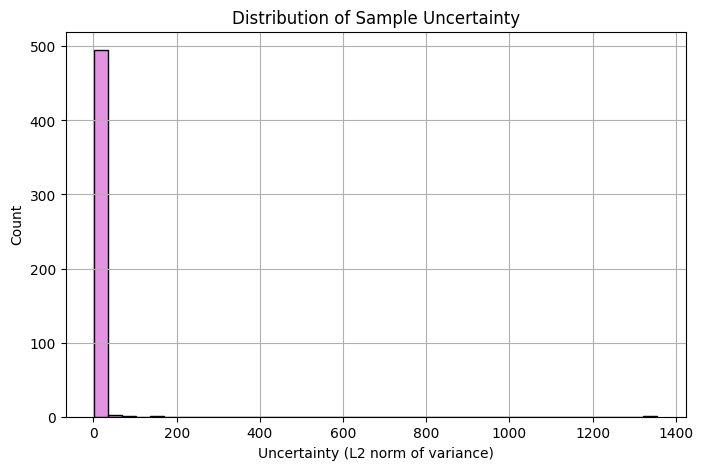

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_uncertainty = np.linalg.norm(uncertainty, axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(sample_uncertainty, bins=40, color='orchid')
plt.xlabel("Uncertainty (L2 norm of variance)")
plt.title("Distribution of Sample Uncertainty")
plt.grid(True)
plt.show()


In [57]:
high_uncertainty_indices = np.where(sample_uncertainty > np.percentile(sample_uncertainty, 95))[0]
print("Highly uncertain samples:", generated_samples[high_uncertainty_indices])


Highly uncertain samples: [[ 2.690655    2.3051054 ]
 [ 4.334422   -1.9761919 ]
 [-4.0821667   4.078707  ]
 [ 1.7749534   2.1838956 ]
 [ 0.9744457   0.7061055 ]
 [ 2.1818779   1.7449313 ]
 [ 5.180149    1.0941821 ]
 [ 1.8869439   2.3810344 ]
 [ 2.7187872   2.8401866 ]
 [ 2.221892    2.9714944 ]
 [ 6.17336    -2.0095508 ]
 [ 1.3636183  -0.58009297]
 [ 0.3897369   0.72961825]
 [ 1.6758368   1.800666  ]
 [-4.1953893   3.9592645 ]
 [-0.42653242 -0.4564968 ]
 [-3.249594    2.6055083 ]
 [-2.7317467   1.8535541 ]
 [-2.6709878   4.925123  ]
 [ 2.3753505   1.0768073 ]
 [ 1.3135318   1.6484993 ]
 [-6.3824      2.967825  ]
 [-0.2106051  -1.2193263 ]
 [ 4.6663423  -2.2414286 ]
 [-1.4678382   0.5884117 ]]


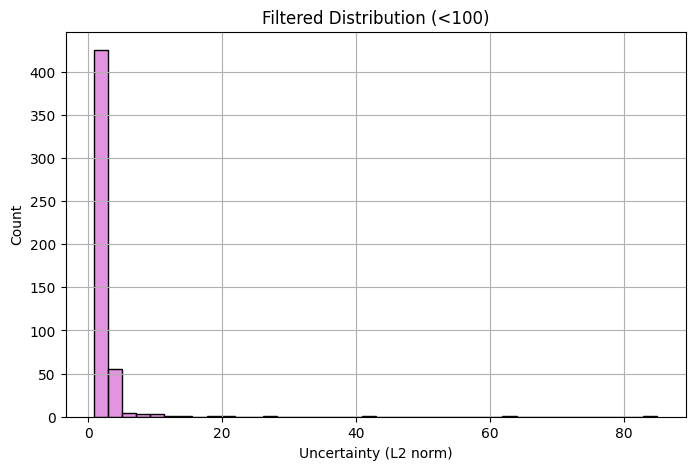

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered = sample_uncertainty[sample_uncertainty < 100]

plt.figure(figsize=(8, 5))
sns.histplot(filtered, bins=40, color='orchid')
plt.xlabel("Uncertainty (L2 norm)")
plt.title("Filtered Distribution (<100)")
plt.grid(True)
plt.show()
